In [ ]:
from IPython.core.magic import register_cell_magic
@register_cell_magic
def skip(line, cell):
    return

import numpy as np
import peak_modeling_R24 as R24
import peak_modeling_C25 as C25
from peaks_for_fitting import *
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.close('all')
plt.ion()
%matplotlib ipympl

In [3]:
T_label  = "$\\tilde{T}$"
nu_label = "$\\nu/\\nu_0$"
nupk_label = "$\\nu_{\\rm pk}/\\nu_0$"
nF_label = "$\\nu F_\\nu / \\nu_0 F_0$"
nFpk_label = "$(\\nu F_\\nu)_{\\rm pk} / \\nu_0 F_0$"
def create_legend_colors(ax, names, colors, **kwargs):
  dummy_col = [ax.plot([], [], c=col, ls='-')[0] for col in colors]
  legend = ax.legend(dummy_col, names, **kwargs)
  return legend

def create_legend_styles(ax, names, styles, **kwargs):
  dummy_lst = [ax.plot([], [], c='k', ls=l)[0] for l in styles]
  legend = ax.legend(dummy_lst, names, **kwargs)
  return legend

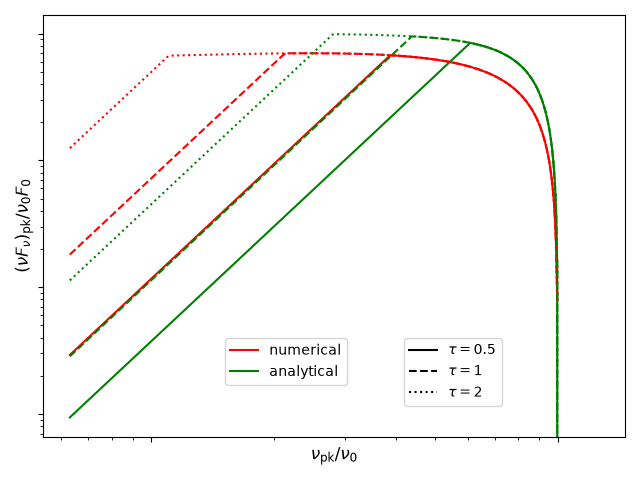

In [4]:

nupks = np.logspace(-1.2, 0.1, 500)
fig, ax = plt.subplots()
au = 2
models = [C25.correlation_model, R24.correlation_model]
colors = ['r', 'g']
tau_arr = [0.5, 1, 2]
linestyles = ['-', '--', ':']
for tau, ls in zip(tau_arr, linestyles):
    corr25 = C25.correlation_model(nupks, au, tau, Tmax=10, renormFlux=False)
    corr24 = R24.correlation_model(nupks, au, tau, renormFlux=False)
    ax.loglog(nupks, corr25, c='r', ls=ls)
    ax.loglog(nupks, corr24, c='g', ls=ls)
legcol = create_legend_colors(ax, ['numerical', 'analytical'], colors,
    bbox_to_anchor=(0.3, 0.25))
leglst = create_legend_styles(ax, [f'$\\tau={tau}$' for tau in tau_arr], linestyles, 
    bbox_to_anchor=(0.8, 0.25))
ax.add_artist(legcol)
ax.tick_params(axis='x', which='both', labelbottom=False)
ax.tick_params(axis='y', which='both', labelleft=False)
plt.xlabel(nupk_label, fontsize=12)
plt.ylabel(nFpk_label, fontsize=12)
fig.tight_layout()
plt.savefig('C25vsR24_corr.png', dpi=300)

Clean freshly copied fullsweep csv files

In [5]:
def clean_sweep_data():
    '''Takes out unnecessary columns from fullsweep files'''
    for front in ['RS', 'FS']:
        fname = f'fullsweep_au_{front}.csv'
        df = pd.read_csv(fname, sep='\t')
        df = df.drop(columns=['Tf', 't_max'])
        todrop = [f'ShSt_{s}' for s in ['A', 'x_b', 'alpha', 's']]
        df = df.drop(columns=todrop)
        df.to_csv(fname, index=False, sep='\t')

Utilitaries to check for max flux vs parameters

In [ ]:
def maximal_nuFnu(peak_model, au, tau, reverse=True,
                  Tmax=5., N=400, return_loc=False):
  '''
  Peak value of (nu F_nu)_pk over the tilde{T} track for a given peak model.

    peak_model:  peak_model callable from peak_modeling_C25 or _R24
    au:          a_u, proper velocity contrast
    tau:         t_on/t_off for the relevant shell (tau4 for RS, tau1 for FS)
    reverse:     True for the reverse shock, False for the forward shock
    Tmax:        track spans tilde{T} in [1, 1+Tmax] (T=1 at collision)
    N:           number of log-spaced points along the track
    return_loc:  if True, also return (T_max, nu_at_max) where the peak occurs

  Returns nFmax, or (nFmax, T_max, nu_max) if return_loc is True.
  '''

  T_track = np.geomspace(1., 1. + Tmax, N)
  nu_track, nF_track = peak_model(T_track, au, tau, reverse, renormFlux=False)

  imax = np.nanargmax(nF_track)
  nFmax = nF_track[imax]

  if return_loc:
    return nFmax, T_track[imax], nu_track[imax]
  return nFmax


def maximal_nuFnu_scan(peak_model, param, values, base_params,
                       return_loc=False, **track_kwargs):
  '''
  Maximal (nu F_nu)_pk as one parameter is varied, holding the others fixed.
  Convenience wrapper to trace how the peak flux evolves with a parameter.

    peak_model:   peak_model callable from peak_modeling_C25 or _R24
    param:        name of the parameter to sweep ('au' or 'tau')
    values:       iterable of values for that parameter
    base_params:  dict of the remaining peak_model parameters, i.e. the other
                    of {'au', 'tau'} plus optionally 'reverse'
    return_loc:   forwarded to maximal_nuFnu
    track_kwargs: Tmax, N forwarded to maximal_nuFnu

  Returns an array nFmax(values); if return_loc, returns (nFmax, T_max, nu_max)
  as parallel arrays.
  '''

  nFmax = np.empty(len(values))
  T_max = np.empty(len(values))
  nu_max = np.empty(len(values))
  for i, v in enumerate(values):
    params = dict(base_params)
    params[param] = v
    out = maximal_nuFnu(peak_model, return_loc=True, **params, **track_kwargs)
    nFmax[i], T_max[i], nu_max[i] = out

  if return_loc:
    return nFmax, T_max, nu_max
  return nFmax

In [6]:
# test binned prediction
def pks_binned_means(T1, T2, au, tau, reverse=True, Nbins=20):
  '''Flux-weighted mean peak energy and mean peak flux'''
  Tlow, Tup = min(T1, T2), max(T1, T2)
  T_bins = np.geomspace(Tlow, Tup, Nbins)
  nu_bins, nF_bins = C25.peak_model(T_bins, au, tau, reverse)
  F_bins = nF_bins/nu_bins
  DT = Tup - Tlow
  int_F  = np.trapezoid(F_bins, T_bins)
  int_nF = np.trapezoid(nF_bins, T_bins)
  ave_nF = int_nF/DT
  ave_nu = int_nF/int_F
  return ave_nu, ave_nF

def S(x, alpha, beta):
  b  = alpha-beta
  xb = b/(1+alpha)
  def S_inf(x):
    return np.exp(1+alpha) * x**alpha * np.exp(-x*(1+alpha))
  def S_sup(x):
    return np.exp(1+alpha) * x**beta * xb**b * np.exp(-b)
  return np.where(x<=xb, S_inf(x), S_sup(x))

def pks_binned_full(T1, T2, au, tau, reverse=True, NT=20, Nnu=200, alpha=-0.5, beta=-1.25):
  T1, T2 = min(T1, T2), max(T1, T2)
  DT = T2-T1
  T_bins = np.geomspace(T1, T2, NT)
  nu_bins, nF_bins = C25.peak_model(T_bins, au, tau, reverse)
  lognu_min, lognu_max = np.log10(nu_bins.min()) - 0.5, np.log10(nu_bins.max()) + 0.5
  nub = np.logspace(lognu_min, lognu_max, Nnu)
  nF_full = np.zeros((NT, Nnu))
  for i, (nupk, nFpk) in enumerate(zip(nu_bins, nF_bins)):
    x = nub/nupk
    nF_full[i] = nFpk * x * S(x, alpha, beta)
  nF_int = np.trapezoid(nF_full, T_bins, axis=0)/DT
  imax = np.argmax(nF_int)
  return nub[imax], nF_int[imax]

In [7]:
%%skip
# Compare pks_binned_means vs pks_binned_full over various time intervals
au, tau = 2, 1

def compare_methods(T1, T2, au, tau, reverse=True, Nbins=50):
    ave_nu, ave_nF = pks_binned_means(T1, T2, au, tau, reverse, Nbins)
    int_nu, int_nF = pks_binned_full(T1, T2, au, tau, reverse, Nbins)
    rel_nu = abs(ave_nu - int_nu) / int_nu
    rel_nF = abs(ave_nF - int_nF) / int_nF
    return ave_nu, int_nu, rel_nu, ave_nF, int_nF, rel_nF

# Build a set of intervals: varying both start point and width
starts = [1.0, 1.2, 1.5, 2.0, 3.0, 4.0]
widths = [0.2, 0.5, 1.0, 2.0]

print(f"{'T1':>5} {'T2':>5} | {'nu_mean':>9} {'nu_full':>9} {'rel_nu':>9} | "
      f"{'nF_mean':>9} {'nF_full':>9} {'rel_nF':>9}")
print('-' * 78)
rel_nu_all, rel_nF_all = [], []
for T1 in starts:
    for w in widths:
        T2 = T1 + w
        a_nu, i_nu, r_nu, a_nF, i_nF, r_nF = compare_methods(T1, T2, au, tau)
        rel_nu_all.append(r_nu); rel_nF_all.append(r_nF)
        print(f"{T1:5.2f} {T2:5.2f} | {a_nu:9.4f} {i_nu:9.4f} {r_nu:9.2%} | "
              f"{a_nF:9.4f} {i_nF:9.4f} {r_nF:9.2%}")

rel_nu_all = np.array(rel_nu_all); rel_nF_all = np.array(rel_nF_all)
print('-' * 78)
print(f"nu_pk relative diff:  max={rel_nu_all.max():.2%}  mean={rel_nu_all.mean():.2%}")
print(f"nF_pk relative diff:  max={rel_nF_all.max():.2%}  mean={rel_nF_all.mean():.2%}")

In [8]:
%%skip
# Computation-time comparison of the two methods
import timeit
au, tau = 2, 1
T1, T2 = 1.5, 2.5

# warm up: first call parses the fit table (lru_cache); don't charge it to the bench
pks_binned_means(T1, T2, au, tau)
pks_binned_full(T1, T2, au, tau)

def bench(fn, number=300):
    return timeit.timeit(fn, number=number) / number * 1e3  # ms per call

t_means = bench(lambda: pks_binned_means(T1, T2, au, tau))
t_full  = bench(lambda: pks_binned_full(T1, T2, au, tau))
# fixed floor: both methods share one peak_model call (default 20 bins)
T_bins = np.geomspace(T1, T2, 20)
t_peak  = bench(lambda: C25.peak_model(T_bins, au, tau))

print(f"peak_model (shared floor) : {t_peak:6.3f} ms")
print(f"pks_binned_means          : {t_means:6.3f} ms  (+{t_means-t_peak:.3f} ms over floor)")
print(f"pks_binned_full           : {t_full:6.3f} ms  (+{t_full-t_peak:.3f} ms over floor)")
print(f"full / means              : {t_full/t_means:.2f}x")

# how pks_binned_full scales with its spectral-grid resolution
print("\npks_binned_full resolution scaling:")
for NT, Nnu in [(20, 200), (20, 500), (50, 500), (100, 1000)]:
    t = bench(lambda NT=NT, Nnu=Nnu: pks_binned_full(T1, T2, au, tau, NT=NT, Nnu=Nnu))
    print(f"  NT={NT:<4} Nnu={Nnu:<5} : {t:6.3f} ms")

Plot peaks and correlation

In [9]:
def plot_peaks(T, au, tau, reverse=True, **kwargs):
  nupk, nFpk = C25.peak_model(T, au, tau, reverse)
  col = 'r' if reverse else 'b'
  fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True)
  ax0.semilogy(T, nupk, c=col, **kwargs)
  ax0.set_ylabel(nupk_label)
  ax1.plot(T, nFpk, c=col, **kwargs)
  ax1.set_ylabel(nFpk_label)
  ax1.set_xlabel(T_label)
  fig.tight_layout()

def plot_correlation(nupks, au, tau, reverse=True, N=500, Tmax=5., **kwargs):
  nFpks = C25.correlation_model(nupks, au, tau, reverse, N, Tmax)
  col = 'r' if reverse else 'b'
  fig, ax = plt.subplots()
  ax.loglog(nupks, nFpks, c=col, **kwargs)
  ax.set_xlabel(nupk_label)
  ax.set_ylabel(nFpk_label)
  fig.tight_layout()


In [10]:
plt.close('all')

In [11]:
au, tau = 2, 1
T_obs = np.linspace(1, 6)
#T_arr = np.arange(1, 5, 0.3)
T_arr = np.array([1.1, 1.5, 2.0, 3.0, 4.5, 5.8])
T_cent = .5 * (T_arr[1:] + T_arr[:-1])
nupk, nFpk = C25.peak_model(T_obs, au, tau)
nu_edges, nF_edges = C25.peak_model(T_arr, au, tau)
ave_nu, ave_nF = correlation_binned(au, tau, T_arr, C25.peak_model)
ave_nu2, ave_nF2 = correlation_binned_full(au, tau, T_arr, C25.peak_model)
T_hf, nu_hf, nF_hf = fluence_halftime(au, tau, T_arr, C25.peak_model)
T_hf2, nu_hf2, nF_hf2 = photon_halftime(au, tau, T_arr, C25.peak_model)

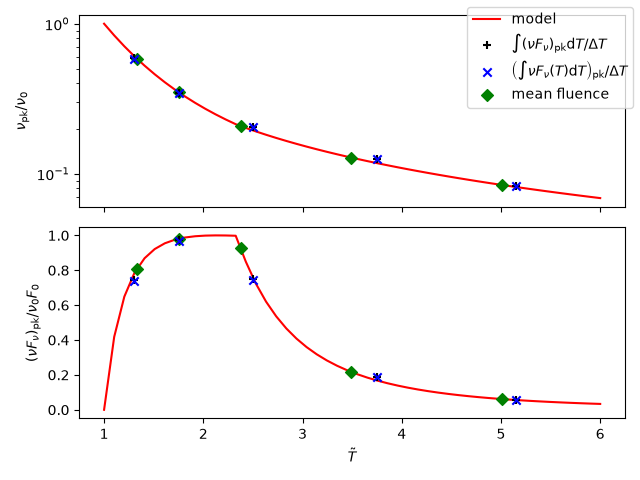

In [12]:
fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True)
line = ax0.semilogy(T_obs, nupk, c='r', zorder=-1)
scat3 = ax0.scatter(T_hf, nu_hf, marker='D', c='g')
scat1 = ax0.scatter(T_cent, ave_nu, marker='+', c='k')
scat2 = ax0.scatter(T_cent, ave_nu2, marker='x', c='b')
ax0.set_ylabel(nupk_label)
ax1.plot(T_obs, nFpk, c='r', zorder=-1)
ax1.scatter(T_hf, nF_hf, marker='D', c='g')
ax1.scatter(T_cent, ave_nF, marker='+', c='k')
ax1.scatter(T_cent, ave_nF2, marker='x', c='b')
ax1.set_ylabel(nFpk_label)
ax1.set_xlabel(T_label)
fig.legend([line[0], scat1, scat2, scat3],
  ['model', '$\\int (\\nu F_\\nu)_{\\rm pk}{\\rm d}T/\\Delta T$', 
    '$\\left(\\int\\nu F_\\nu(T){\\rm d}T\\right)_{\\rm pk}/\\Delta T$', 'mean fluence'])
fig.tight_layout()

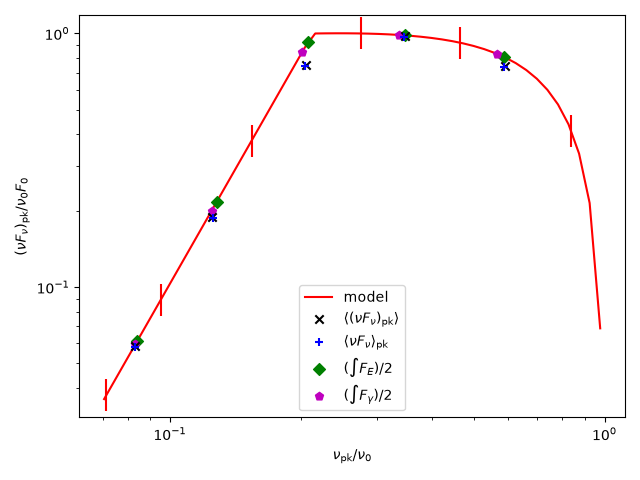

In [13]:
nupks = np.logspace(-1.2, -0.01)
nFpks = C25.correlation_model(nupks, au, tau)

fig, ax = plt.subplots()
line = ax.loglog(nupks, nFpks, c='r', zorder=-1)
scat3 = ax.scatter(nu_hf, nF_hf, marker='D', c='g')
scat4 = ax.scatter(nu_hf2, nF_hf2, marker='p', c='m')
scat1 = ax.scatter(ave_nu, ave_nF, marker='x', c='k')
scat2 = ax.scatter(ave_nu2, ave_nF2, marker='+', c='b')
ax.scatter(nu_edges, nF_edges, s=5e2, marker='|', c='r')
ax.set_xlabel(nupk_label)
ax.set_ylabel(nFpk_label)
ax.legend([line[0], scat1, scat2, scat3, scat4], 
  #['model', '$\\int (\\nu F_\\nu)_{\\rm pk}{\\rm d}T/\\Delta T$', 
  #  '$\\left(\\int\\nu F_\\nu(T){\\rm d}T\\right)_{\\rm pk}/\\Delta T$', 'mean fluence'],
  ['model', '$\\langle (\\nu F_\\nu)_{\\rm pk} \\rangle$', 
    '$\\langle \\nu F_\\nu\\rangle_{\\rm pk} $', '$(\\int F_E)/2$', '$(\\int F_\\gamma)/2$'],
  loc='lower center')
fig.tight_layout()
plt.savefig('correlation_estimate.png', dpi=300)

In [14]:
%%skip
nupks = np.logspace(-1.2, 0.1, 500)
fig, ax = plt.subplots()
colors = mpl.color_sequences['Set1']
au_arr = 1+ 10.**np.array([-1., 0, 1])
colors = colors[:len(au_arr)]
tau_arr = [0.5, 1, 2]
linestyles = ['-', '--', ':']
for au, col in zip(au_arr, colors):
  for tau, ls in zip(tau_arr, linestyles):
    corr = C25.correlation_model(nupks, au, tau, Tmax=10)
    ax.loglog(nupks, corr, c=col, ls=ls)
legcol = create_legend_colors(ax, [f'$a_u={au:.1f}$' for au in au_arr], colors,
    bbox_to_anchor=(0.3, 0.25))
leglst = create_legend_styles(ax, [f'$\\tau={tau}$' for tau in tau_arr], linestyles, 
    bbox_to_anchor=(0.8, 0.25))
ax.add_artist(legcol)
plt.xlabel(nupk_label)
plt.ylabel(nFpk_label)
fig.tight_layout()
plt.savefig('corr_C25.png', dpi=300)

In [15]:
%%skip
def compare_correl(nupks, au, tau, reverse=True, ax_in=None, **kwargs):
  nF_C25 = C25.correlation_model(nupks, au, tau, reverse=reverse, Tmax=10)
  nF_R24 = R24.correlation_model(nupks, au, tau, reverse=reverse)

  if ax_in is None:
    fig, ax = plt.subplots()
  else:
    ax = ax_in
  ax.loglog(nupks, nF_C25, ls='-', **kwargs)
  ax.loglog(nupks, nF_R24, ls='--', **kwargs)

nupks = np.logspace(-1.5, 0.1, 200)
fig, ax = plt.subplots()
colors = mpl.color_sequences['Set1']
au_arr = 1+ 10.**np.array([-1., 0, 1])
colors = colors[:len(au_arr)]
for au, col in zip(au_arr, colors):
  compare_correl(nupks, au, 1, ax_in=ax, c=col)
ax.set_ylabel(nFpk_label)
ax.set_xlabel(nupk_label)
legcol = create_legend_colors(ax, [f'$a_u={au:.1f}$' for au in au_arr], colors,
    bbox_to_anchor=(0.5, 0.2))
create_legend_styles(ax, ['C25', 'R24'], ['-', '--'],
    bbox_to_anchor=(0.8, 0.2))
ax.add_artist(legcol)

[]

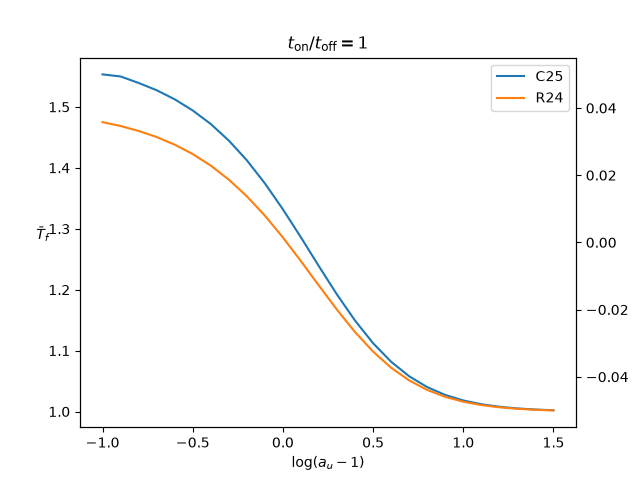

In [16]:

tau = 1
logau_arr = np.arange(-1, 1.6, 0.1)
Tf_C25, Tf_R24 = [], []
for logau in logau_arr:
  au = 1 + 10**logau
  popts = C25.fitparams_from_au(au)
  popt_lfac = popts[0]
  Tf_C25.append(C25.compute_Tf(tau, au, popt_lfac)[0] - 1)
  K = C25.tau_to_dRR0_cst(au)[0]
  Tf_R24.append(K*tau)
plt.figure()
plt.plot(logau_arr, Tf_C25, label='C25')
plt.plot(logau_arr, Tf_R24, label='R24')
plt.legend()
plt.xlabel('log$(a_u-1)$')
plt.ylabel('$\\bar{T}_f$', rotation='horizontal')
plt.title(f'$t_{{\\rm on}}/t_{{\\rm off}}={tau}$')
plt.twinx()
plt.plot()

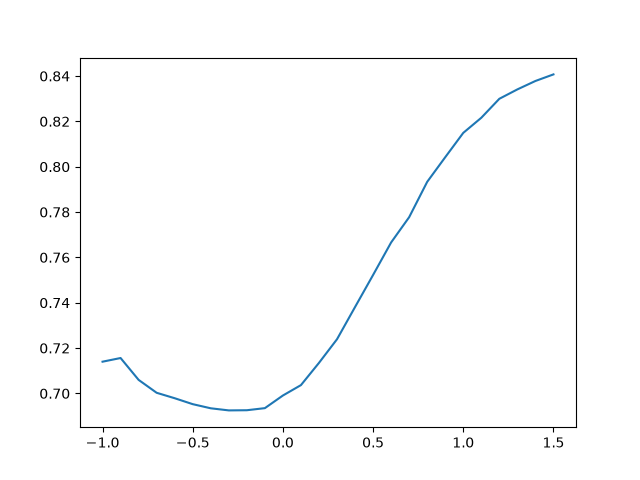

In [17]:
tau = 1
logau_arr = np.arange(-1, 1.6, 0.1)
au_arr = 10.**logau_arr + 1
nF_maxs = maximal_nuFnu_scan(C25.peak_model, 'au', au_arr, {'tau':tau, 'reverse':True})
plt.figure()
plt.plot(logau_arr, nF_maxs)

bin          mid    T_half
[1.0,1.5]  1.250  1.315
[1.5,2.0]  1.750  1.755
[2.0,3.0]  2.500  2.376
[3.0,4.5]  3.750  3.492
[4.5,6.0]  5.250  5.072


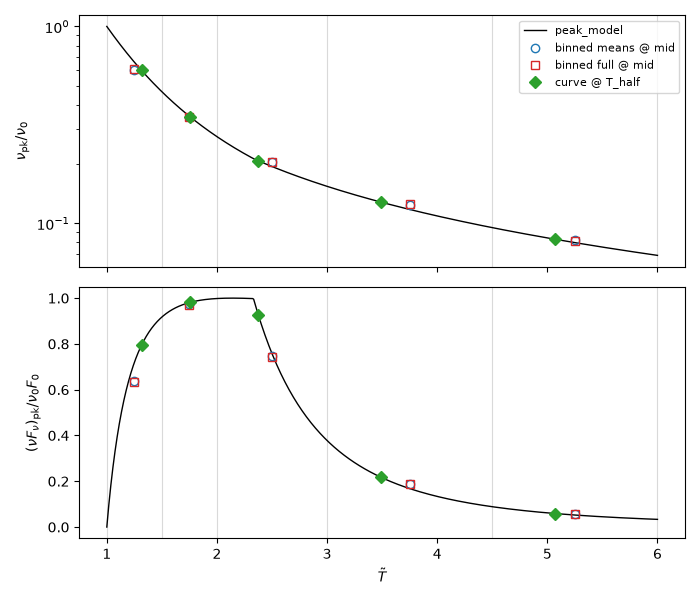

In [19]:
au, tau, reverse = 2, 1, True
peak_model = C25.peak_model
Tarr = np.array([1.0, 1.5, 2.0, 3.0, 4.5, 6.0])   # bin edges
mid = 0.5*(Tarr[:-1] + Tarr[1:])                   # geometric midpoint

# binned representative peaks (two methods) + half-fluence time of each bin
nu_m, nF_m = correlation_binned(au, tau, Tarr, peak_model, reverse)
nu_f, nF_f = correlation_binned_full(au, tau, Tarr, peak_model, reverse)
T_half, nu_h, nF_h = fluence_halftime(au, tau, Tarr, peak_model, reverse)

# reference track
T_curve = np.geomspace(Tarr[0], Tarr[-1], 500)
nu_curve, nF_curve = peak_model(T_curve, au, tau, reverse)

fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, figsize=(7, 6))
for ax, ycurve, ym, yf, yh, lab in [
        (ax0, nu_curve, nu_m, nu_f, nu_h, nupk_label),
        (ax1, nF_curve, nF_m, nF_f, nF_h, nFpk_label)]:
    ax.plot(T_curve, ycurve, 'k-', lw=1, label='peak_model')
    ax.plot(mid, ym, 'o', mfc='none', c='tab:blue',  label='binned means @ mid')
    ax.plot(mid, yf, 's', mfc='none', c='tab:red',   label='binned full @ mid')
    ax.plot(T_half, yh, 'D', c='tab:green',          label='curve @ T_half')
    for e in Tarr:
        ax.axvline(e, color='0.85', lw=0.8, zorder=0)
    ax.set_ylabel(lab)
ax0.set_yscale('log')
ax0.legend(fontsize=8)
ax1.set_xlabel(T_label)
fig.tight_layout()

print("bin          mid    T_half")
for k in range(len(mid)):
    print(f"[{Tarr[k]:.1f},{Tarr[k+1]:.1f}]  {mid[k]:.3f}  {T_half[k]:.3f}")